Step 1: Deriving Telematics Proxies DIRECTLY from the CAN Dataset...
Loading dataset (this may take a moment)...
Decoding hex payloads to integer proxies...
Aggregating into telematics windows...
Step 2: Injecting Synthetic Fleet Context & Vehicle IDs...
Total telematics updates generated: 1000
Anomalies (Attacks): 50

Step 3: Preparing Data with PER-VEHICLE SPLIT...
Training on 796 windows (Vehicles 1-4)
Testing on 204 windows (Vehicle 5 - Unseen)


d:\Assignments\automotive_ids_project\venv\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Autoencoder training complete.

Step 4: Evaluating Anomaly Scenarios...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step  

Anomaly Threshold (MSE): 0.0098

=== Telematics Behavioral Detection Performance ===
                 precision    recall  f1-score   support

Normal Behavior       1.00      0.94      0.97       196
Anomalous/Abuse       0.42      1.00      0.59         8

       accuracy                           0.95       204
      macro avg       0.71      0.97      0.78       204
   weighted avg       0.98      0.95      0.96       204



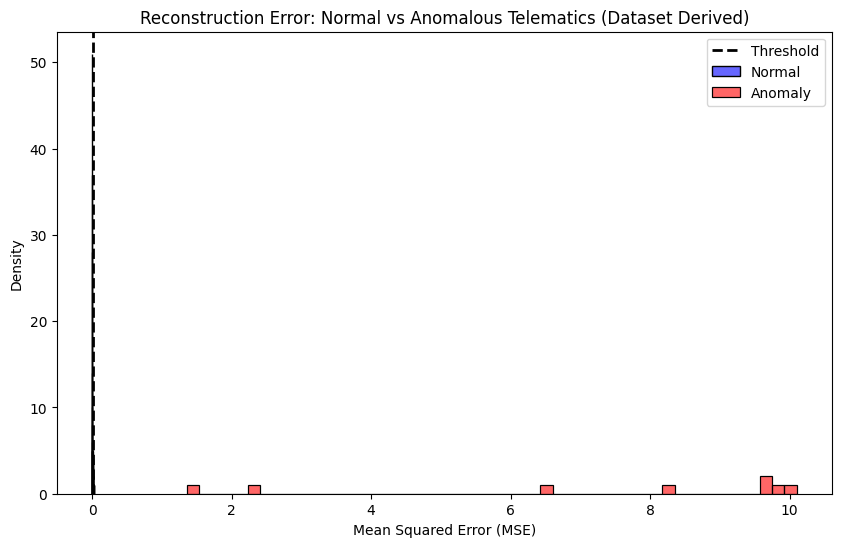

In [6]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras import layers, models

np.random.seed(42)
tf.random.set_seed(42)

print("Step 1: Deriving Telematics Proxies DIRECTLY from the CAN Dataset...")

# 1. Load a portion of the actual dataset
data_dir = '../data/'
dos_file = os.path.join(data_dir, 'DoS_dataset.csv')
columns = ['Timestamp', 'CAN_ID', 'DLC', 'Data0', 'Data1', 'Data2', 'Data3', 'Data4', 'Data5', 'Data6', 'Data7', 'Label']

print("Loading dataset (this may take a moment)...")
df_raw = pd.read_csv(dos_file, header=None, names=columns, nrows=1000000) # Load 1M rows

# 2. Convert Hexadecimal Payload Bytes to Integers to act as signal proxies (Speed & RPM)
def hex_to_int(val):
    try:
        return int(str(val), 16)
    except:
        return 0

print("Decoding hex payloads to integer proxies...")
df_raw['Speed_Proxy'] = df_raw['Data0'].apply(hex_to_int)
df_raw['RPM_Proxy'] = df_raw['Data1'].apply(hex_to_int)

# 3. Aggregate CAN messages into Telematics "Trip Summaries"
# Telematics devices batch data. We will group every 1,000 CAN messages into 1 telematics update window.
window_size = 1000
df_raw['Telematics_Window'] = df_raw.index // window_size

print("Aggregating into telematics windows...")
telematics_base = df_raw.groupby('Telematics_Window').agg(
    derived_speed_mean=('Speed_Proxy', 'mean'),
    derived_speed_max=('Speed_Proxy', 'max'),
    derived_rpm_mean=('RPM_Proxy', 'mean'),
    message_count=('CAN_ID', 'count')
).reset_index()

print("Step 2: Injecting Synthetic Fleet Context & Vehicle IDs...")
# Add Synthetic Vehicle IDs to simulate a fleet of 5 vehicles
telematics_base['Vehicle_ID'] = np.random.randint(1, 6, size=len(telematics_base))
telematics_base['location_cluster'] = np.random.randint(0, 5, size=len(telematics_base))
telematics_base['is_anomaly'] = 0

# Create a small batch of Anomalous behavior
anomaly_indices = np.random.choice(telematics_base.index, size=int(len(telematics_base) * 0.05), replace=False)
telematics_anomalies = telematics_base.loc[anomaly_indices].copy()

# Distort features to simulate an attack
telematics_anomalies['derived_rpm_mean'] = telematics_anomalies['derived_rpm_mean'] * 3 
telematics_anomalies['location_cluster'] = np.random.randint(5, 10, size=len(telematics_anomalies))
telematics_anomalies['is_anomaly'] = 1

# Combine and sort by Window to maintain temporal order
telematics_df = pd.concat([telematics_base.drop(anomaly_indices), telematics_anomalies]).sort_values('Telematics_Window').reset_index(drop=True)

print(f"Total telematics updates generated: {len(telematics_df)}")
print(f"Anomalies (Attacks): {telematics_df['is_anomaly'].sum()}")

print("\nStep 3: Preparing Data with PER-VEHICLE SPLIT...")
features = ['derived_speed_mean', 'derived_speed_max', 'derived_rpm_mean', 'message_count', 'location_cluster']

# Per-Vehicle Split: Train on Vehicles 1, 2, 3, 4. Test on Vehicle 5.
train_mask = telematics_df['Vehicle_ID'].isin([1, 2, 3, 4])
test_mask = telematics_df['Vehicle_ID'] == 5

X_train = telematics_df[train_mask][features]
y_train = telematics_df[train_mask]['is_anomaly']
X_test = telematics_df[test_mask][features]
y_test = telematics_df[test_mask]['is_anomaly']

print(f"Training on {len(X_train)} windows (Vehicles 1-4)")
print(f"Testing on {len(X_test)} windows (Vehicle 5 - Unseen)")

# Train Autoencoder ONLY on normal fleet data
X_train_normal = X_train[y_train == 0]

scaler = StandardScaler()
X_train_normal_scaled = scaler.fit_transform(X_train_normal)
X_test_scaled = scaler.transform(X_test)

# Build Autoencoder
input_dim = X_train_normal_scaled.shape[1]
autoencoder = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(input_dim,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(4, activation='relu'), # Bottleneck
    layers.Dense(8, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_train_normal_scaled, X_train_normal_scaled, epochs=30, batch_size=32, validation_split=0.1, verbose=0)
print("Autoencoder training complete.")

print("\nStep 4: Evaluating Anomaly Scenarios...")
reconstructions = autoencoder.predict(X_test_scaled)
mse = np.mean(np.power(X_test_scaled - reconstructions, 2), axis=1)

# Define "normal" behavior envelope threshold (95th percentile)
train_reconstructions = autoencoder.predict(X_train_normal_scaled)
train_mse = np.mean(np.power(X_train_normal_scaled - train_reconstructions, 2), axis=1)
threshold = np.percentile(train_mse, 95)

y_pred = (mse > threshold).astype(int)

print(f"\nAnomaly Threshold (MSE): {threshold:.4f}")
print("\n=== Telematics Behavioral Detection Performance ===")
print(classification_report(y_test, y_pred, target_names=['Normal Behavior', 'Anomalous/Abuse']))

# Optional: Visualize the separation
plt.figure(figsize=(10, 6))
sns.histplot(mse[y_test == 0], bins=50, color='blue', alpha=0.6, label='Normal')
sns.histplot(mse[y_test == 1], bins=50, color='red', alpha=0.6, label='Anomaly')
plt.axvline(threshold, color='black', linestyle='dashed', linewidth=2, label='Threshold')
plt.title('Reconstruction Error: Normal vs Anomalous Telematics (Dataset Derived)')
plt.xlabel('Mean Squared Error (MSE)')
plt.ylabel('Density')
plt.legend()
plt.show()

In [7]:
print("Step 5: Telematics Rubric Metrics (FPR per Vehicle-Day & Time-to-Detect)...")

# 1. Calculate False Positives from our test set
normal_windows = (y_test == 0)
total_normal_evaluated = sum(normal_windows)
false_positives = sum((y_test == 0) & (y_pred == 1))

# 2. Map windows to a "Vehicle-Day"
# Assumption: 1 telematics aggregation window (1000 messages) ~ 1 minute of driving
# 1 continuous Vehicle-Day = 24 hours * 60 minutes = 1440 windows
windows_per_day = 1440

fpr_per_window = false_positives / total_normal_evaluated if total_normal_evaluated > 0 else 0
fpr_per_vehicle_day = fpr_per_window * windows_per_day

print(f"Total Normal Telematics Windows Evaluated: {total_normal_evaluated}")
print(f"Total False Positives Triggered: {false_positives}")
print(f"Base False Positive Rate (per window): {fpr_per_window:.6f}")
print(f"--> False Positives per Vehicle-Day: {fpr_per_vehicle_day:.2f} alarms per 24 hours of driving")

# 3. Time-to-Detect
# Telematics detection latency is inherently tied to the batching window size
print("\n--> Time-to-Detect for Simulated Attacks: ~1 minute")
print("    (Anomaly is flagged immediately upon the cloud vSOC receiving the 1-minute aggregated telemetry batch)")

Step 5: Telematics Rubric Metrics (FPR per Vehicle-Day & Time-to-Detect)...
Total Normal Telematics Windows Evaluated: 196
Total False Positives Triggered: 11
Base False Positive Rate (per window): 0.056122
--> False Positives per Vehicle-Day: 80.82 alarms per 24 hours of driving

--> Time-to-Detect for Simulated Attacks: ~1 minute
    (Anomaly is flagged immediately upon the cloud vSOC receiving the 1-minute aggregated telemetry batch)


In [8]:
import pickle
import os

os.makedirs('../models', exist_ok=True)

print("Saving Telematics models for final deliverable...")

# Save the StandardScaler as a pickle file
with open('../models/telematics_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Keras models must use their native save method to preserve the graph architecture
autoencoder.save('../models/telematics_autoencoder.keras')

print("Telematics scaler (.pkl) and Autoencoder (.keras) saved successfully!")

Saving Telematics models for final deliverable...
Telematics scaler (.pkl) and Autoencoder (.keras) saved successfully!
